In [2]:
import numpy as np
from scipy.stats import beta as sp_beta
import ipywidgets as widgets
from IPython.display import display

# Jupyter cell (index 0)
# Interactive Beta distribution visualizer with sliders for the two shape parameters.
import matplotlib.pyplot as plt


def plot_beta(alpha, beta):
    x = np.linspace(0, 1, 1000)
    y = sp_beta.pdf(x, alpha, beta)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, y, lw=2, label="PDF")
    ax.fill_between(x, y, alpha=0.2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(y) * 1.1 if max(y) > 0 else 1)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_title(f"Beta PDF — alpha={alpha:.2f}, beta={beta:.2f}")
    mean = alpha / (alpha + beta)
    var = (alpha * beta) / ((alpha + beta) ** 2 * (alpha + beta + 1))
    mode = (alpha - 1) / (alpha + beta - 2)
    concentration = alpha + beta - 2
    ax.axvline(mean, color="red", linestyle="--", label=f"mean={mean:.3f}")
    ax.axvline(mode, color="orange", linestyle="--", label=f"mode={mode:.3f}")
    ax.legend()
    plt.show()
    print(f"{mean=:.3f} {var=:.3f} {mode=:.3f} {concentration=:.3f}")

In [2]:
# min = 1 as pdf diverges when alpha/beta < 1
alpha_slider = widgets.FloatSlider(
    value=2.0,
    min=1,
    max=10.0,
    step=0.1,
    description="alpha",
    continuous_update=True,
    readout_format=".1f",
)
beta_slider = widgets.FloatSlider(
    value=2.0,
    min=1,
    max=10.0,
    step=0.1,
    description="beta",
    continuous_update=True,
    readout_format=".1f",
)

controls = widgets.HBox([alpha_slider, beta_slider])
out = widgets.interactive_output(
    plot_beta, {"alpha": alpha_slider, "beta": alpha_slider}
)

display(widgets.VBox([controls, out]))

In [3]:
mode = 0
lmd = 0
alpha = 1 + lmd * mode
beta = 1 + lmd * (1 - mode)

In [4]:
def plot_beta_pert(mode, lmd):
    alpha = 1 + lmd * mode
    beta = 1 + lmd * (1 - mode)
    plot_beta(alpha, beta)

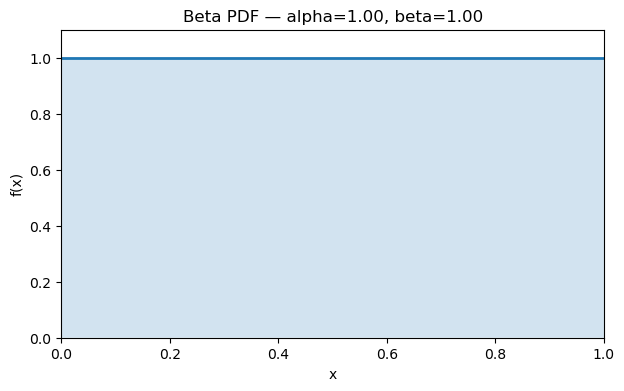

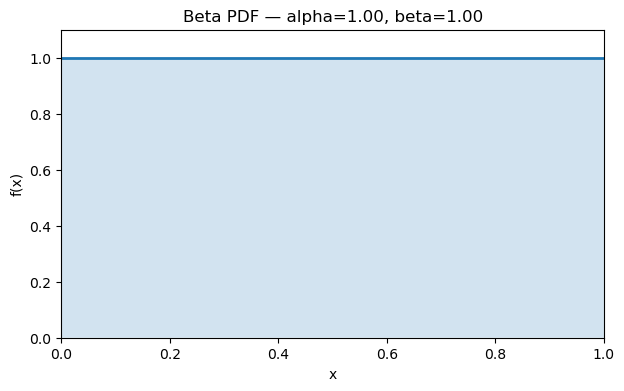

In [5]:
# min = 1 as pdf diverges when alpha/beta < 1
mode_slider = widgets.FloatSlider(
    value=1 / 2,
    min=0,
    max=1,
    step=0.05,
    description="mode",
    continuous_update=True,
    readout_format=".2f",
)
lmd_slider = widgets.FloatSlider(
    value=1,
    min=0,
    max=100,
    step=0.1,
    description="lambda",
    continuous_update=True,
    readout_format=".1f",
)

controls = widgets.HBox([mode_slider, lmd_slider])
out = widgets.interactive_output(
    plot_beta_pert,
    {"mode": mode_slider, "lmd": lmd_slider},
)

display(widgets.VBox([controls, out]))

In [7]:
import torch
from torch.distributions import Beta, kl_divergence

In [ ]:
def BetaPERT(m=torch.tensor(0.5), lmd=torch.tensor(4)):
    alpha = 1 + lmd * m
    beta = 1 + lmd * (1 - m)
    return Beta(alpha, beta)

In [4]:
a = BetaPERT(1, 3)
b = BetaPERT()

In [8]:
kl_divergence(a, b)

tensor(1.9018)

In [9]:
kl_divergence(a, a)

tensor(0.)

In [11]:
kl_divergence(b, a)

tensor(1.2316)

In [ ]:
import torch

u = 0
alpha = torch.tensor(1.5)
beta = torch.tensor(1.5)

nll_w = -(
    u * torch.digamma(alpha)
    + (1 - u) * torch.digamma(beta)
    - torch.digamma(alpha + beta)
)

nll_w

tensor(0.8863)